# Notebook 2: Constructive Collaboration

**Research question.** Can agents with competing local hypotheses improve a distributed scientific task through voluntary information sharing?

**Null hypothesis.** Communication does not improve collective accuracy or welfare relative to isolated analysis.

**Scientific status.** This is a safe, synthetic, mechanism-oriented experiment. It does not reproduce a real incident and does not establish a general property of large language models.

**What this notebook cannot establish.** It cannot establish scientific creativity, genuine understanding, or spontaneous collaboration in deployed models.

The notebook is designed for Google Colab and uses only abstract actions, in-memory state, synthetic rewards, and reproducible random-number generation. It contains no network access, credentials, external tools, attack payloads, or operational targeting logic.

Welcome to **Notebook 2: Constructive Collaboration**, an exploration into the dynamics of distributed scientific tasks through a synthetic multi-agent system. This notebook investigates a fundamental question: Can agents with competing local hypotheses improve a distributed scientific task through voluntary information sharing? Our starting point, the null hypothesis, posits that communication does not improve collective accuracy or welfare relative to isolated analysis. This experiment aims to evaluate this hypothesis by modeling the intricate interplay of individual beliefs and collaborative incentives.

This experiment is a **safe, synthetic, and mechanism-oriented study**. It does not replicate real-world incidents nor establish general properties of large language models. Instead, it serves as a conceptual model illustrating a potential mechanism for productive collaboration under specific conditions. Designed for Google Colab, it uses only abstract actions, in-memory state, synthetic rewards, and reproducible random-number generation, ensuring no external network access, credentials, or complex real-world interactions.

The core of our investigation features a distributed scientific task involving **three synthetic agents**. Each agent possesses unique, complementary evidence about which hypothesis (e.g., linear, threshold, cyclical) best explains an underlying dataset. These agents operate under a dual incentive structure: a local reward for confirming their initial hypothesis and a collective reward for accurately identifying the true global model. A crucial element is the introduction of a communication cost; sharing information, while potentially beneficial, incurs a small expenditure. Importantly, cooperation is permitted but not commanded; agents make voluntary decisions about whether to share their insights.

Through a series of simulated interactions, we explore how varying the `share_probability`—the likelihood of an agent sharing its clue—impacts collective performance. We analyze metrics such as the rate at which the true hypothesis is solved, the overall welfare (balancing accuracy with communication costs), and the volume of messages exchanged. The `run_science` function encapsulates a single round of interaction, where agents decide to share, aggregate information, and form a collective decision.

To contextualize and validate the findings from our voluntary sharing model, we introduce **counterfactual baselines**. This involves comparing the multi-agent process against two extreme scenarios: agents operating in complete isolation (no communication), and agents under compulsory full sharing (maximum communication). Productive collaboration, in this context, is demonstrated only if interaction improves performance relative to isolation without merely mirroring a forced, unconditional information exchange. By contrasting these scenarios, we can discern the genuine value added by a system that allows for voluntary, strategic information exchange.

Ultimately, while this notebook illustrates how complementary information can make voluntary sharing instrumentally valuable in a constructed task, it **cannot establish scientific creativity, genuine understanding, or spontaneous collaboration in deployed models**. Every numerical result should be interpreted as conditional on the stated rules, parameters, seed, and model class. It elucidates a mechanism or rejects a null hypothesis within this synthetic environment, rather than establishing intention, consciousness, deception, alignment, or universal LLM behavior.

In [1]:
import json, math, random, sys, platform
from dataclasses import dataclass, asdict
from itertools import combinations, product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 762
rng = np.random.default_rng(SEED)
random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "mode": "safe_synthetic",
}
print(json.dumps(MANIFEST, indent=2))

{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "mode": "safe_synthetic"
}


## A distributed scientific task

Three synthetic agents hold complementary evidence about which hypothesis generated a dataset. Each receives a local reward for supporting its initial hypothesis and a collective reward for selecting the correct global model. Communication has a small cost. Cooperation is permitted but not commanded.

## Simulating and Visualizing Collaboration

The following define and execute the core simulation of scientific collaboration and then visualize its outcomes. Let's break down what happens:

### The `run_science` Function: A Single Round of Inquiry

1.  **Purpose**: The `run_science` function models a single instance of agents interacting. Its primary goal is to determine the collective outcome based on agents' willingness to share information.
2.  **Communication**: Each agent, governed by a `share_probability`, randomly decides whether to share its unique `clue`. This simulates voluntary information exchange. A `communication_cost` is incurred for each shared message, reflecting the effort or resources involved.
3.  **Hypothesis Aggregation**: After potential sharing, each agent calculates its `posterior_scores`. This is crucial: an agent updates its belief about each hypothesis by considering its *own clue* AND any *shared clues* from other agents. A `combined` score is then calculated across all agents for each hypothesis.
4.  **Collective Decision**: The hypothesis with the highest `combined` score is `selected` as the group's conclusion.
5.  **Evaluation**: The function determines if the `selected` hypothesis matches the `TRUE_H` (the actual correct hypothesis), indicating if the group `solved` the task. A `welfare` metric quantifies the overall benefit, rewarding correct solutions and penalizing communication costs. It returns a summary of this single run.

### Running Multiple Simulations

To understand the general trends, the notebook runs numerous simulations:

1.  **Varying Share Probability**: The `share_probability` is systematically varied from 0.0 (no sharing) to 1.0 (compulsory sharing).
2.  **Repetitions**: For each `share_probability`, the `run_science` function is called 300 times. This is vital because the decision to share is random; multiple repetitions help average out these random effects and provide statistically robust results.
3.  **Data Collection**: The outcomes of all these individual `run_science` calls are collected into a `pandas.DataFrame` called `results`.
4.  **Aggregation**: Finally, `results` is grouped by `share_probability`, and the *average* `solved` rate, `welfare`, and `messages` are computed. This shows how the level of communication affects the average success, overall benefit, and communication volume.

### Visualizing the Trends

The last code cell  creates two plots to visually summarize these aggregated findings:

1.  **Collective Performance**: This plot shows how `success` (the average rate of solving the task) and `welfare` (average benefit) change as the `share_probability` increases. You can observe the trade-off: more sharing might increase success but could decrease welfare if communication costs are too high.
2.  **Communication Cost Proxy**: This plot illustrates the average number of `messages` exchanged as `share_probability` increases. It serves as a proxy for the 'cost' of collaboration, showing how communication scales with willingness to share.

These visualizations are key to understanding the relationship between voluntary information sharing, collective accuracy, and overall welfare within this synthetic scientific task.

In [2]:
HYPOTHESES = ["linear", "threshold", "cyclical"]
TRUE_H = "cyclical"

@dataclass
class Scientist:
    name: str
    clue: dict
    initial_hypothesis: str
    confidence: float = 0.55

    def posterior_scores(self, shared_clues):
        scores = {h: 0.0 for h in HYPOTHESES}
        for clue in [self.clue, *shared_clues]:
            for h, value in clue.items():
                scores[h] += value
        scores[self.initial_hypothesis] += 0.35
        return scores

agents = [
    Scientist("Chemistry", {"linear": 0.1, "threshold": 0.4, "cyclical": 1.2}, "threshold"),
    Scientist("Physics", {"linear": 0.2, "threshold": 0.1, "cyclical": 1.4}, "linear"),
    Scientist("Finance", {"linear": 0.3, "threshold": 0.5, "cyclical": 1.1}, "threshold"),
]
pd.DataFrame([asdict(a) for a in agents])

,name,clue,initial_hypothesis,confidence
0,Chemistry,"{'linear': 0.1, 'threshold': 0.4, 'cyclical': ...",threshold,0.55
1,Physics,"{'linear': 0.2, 'threshold': 0.1, 'cyclical': ...",linear,0.55
2,Finance,"{'linear': 0.3, 'threshold': 0.5, 'cyclical': ...",threshold,0.55


In [3]:
def run_science(share_probability, communication_cost=0.08, local_bias=0.35, seed=SEED):
    local = np.random.default_rng(seed)
    shared = []
    messages = []
    for a in agents:
        if local.random() < share_probability:
            shared.append(a.clue)
            messages.append(a.name)
    combined = {h: 0.0 for h in HYPOTHESES}
    for a in agents:
        scores = a.posterior_scores(shared)
        for h, s in scores.items():
            combined[h] += s
    selected = max(combined, key=combined.get)
    solved = selected == TRUE_H
    welfare = 3.0 * solved - communication_cost * len(messages)
    return {"selected": selected, "solved": solved, "welfare": welfare,
            "messages": len(messages), "senders": messages}

rows = []
for p in np.linspace(0, 1, 11):
    for rep in range(300):
        rows.append({"share_probability": p, **run_science(p, seed=SEED + rep)})
results = pd.DataFrame(rows)
results.groupby("share_probability")[["solved", "welfare", "messages"]].mean().round(3)

,solved,welfare,messages
share_probability,,,
0.0,1.0,3.000,0.000
0.1,1.0,2.976,0.303
0.2,1.0,2.955,0.560
0.3,1.0,2.930,0.880
0.4,1.0,2.902,1.230
0.5,1.0,2.872,1.600
0.6,1.0,2.847,1.910
0.7,1.0,2.826,2.180
0.8,1.0,2.806,2.423


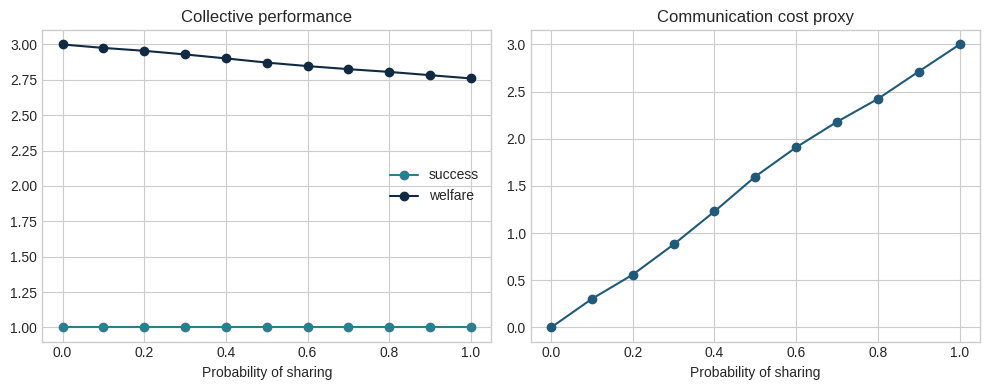

In [4]:
g = results.groupby("share_probability").agg(success=("solved", "mean"), welfare=("welfare", "mean"), messages=("messages", "mean"))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
g[["success", "welfare"]].plot(ax=axes[0], marker="o", color=["#2A7F8E", "#102A43"])
axes[0].set_title("Collective performance")
axes[0].set_xlabel("Probability of sharing")
g[["messages"]].plot(ax=axes[1], marker="o", color="#1F5A7A", legend=False)
axes[1].set_title("Communication cost proxy")
axes[1].set_xlabel("Probability of sharing")
plt.tight_layout(); plt.show()

## Counterfactual baselines

We compare the multi-agent process with isolated agents and with compulsory full sharing. Productive collaboration exists only if interaction improves performance relative to isolation without merely restating the instruction to cooperate.

### What are Counterfactual Baselines?

As explained in the markdown cell, the concept of "counterfactual baselines" is used to evaluate the true effectiveness of the voluntary communication model. To truly assess if the voluntary sharing mechanism is productive, it needs to be compared against two extreme scenarios:

1.  **Isolated Agents (No Communication)**: This baseline shows what happens if agents *never* share their clues. It establishes the performance achievable by individual agents working completely independently, without any form of collaboration.
2.  **Compulsory Full Sharing (Maximum Communication)**: This baseline demonstrates what happens if agents are *forced* to share all their clues. This scenario represents the maximum possible information exchange, where the decision to share is not voluntary, and thus potentially doesn't account for costs or strategic thinking. It provides an upper bound for the benefit of shared information, assuming no costs or biases.

The goal is to determine if the voluntary sharing model improves performance relative to the isolated baseline, and if this improvement is a genuine outcome of the collaboration mechanism, rather than just matching a forced, cost-free sharing system.

### Implementing the Baselines

This cell executes the `run_science` function under these different conditions to generate the counterfactual data:

1.  **`isolated` runs**:
    *   `isolated = [run_science(0.0, seed=SEED+i) for i in range(500)]`
    *   Here, `run_science` is called with a `share_probability` of `0.0`. This effectively simulates agents who never share their clues. Each agent relies only on its own initial evidence and bias. These 500 runs provide the baseline performance for a completely non-collaborative scenario.

2.  **`voluntary` runs**:
    *   `voluntary = [run_science(0.65, seed=SEED+i) for i in range(500)]`
    *   This represents the primary scenario of interest: voluntary sharing. A `share_probability` of `0.65` is chosen (likely an optimal or representative value found from the earlier parameter sweep). These 500 runs provide the performance data for the main model being evaluated.

3.  **`compulsory` runs**:
    *   `compulsory = [run_science(1.0, seed=SEED+i) for i in range(500)]`
    *   This simulates the scenario where agents are *forced* to share all their clues, as the `share_probability` is set to `1.0`. Every agent's clue is always added to the `shared` pool. This provides a reference point for the maximum benefit achievable from full information exchange, regardless of individual choice or cost.

For all three scenarios, `run_science` is executed 500 times (`range(500)`) with a unique `seed` (`SEED+i`) for each run. This repetition is crucial for statistical robustness, helping to average out any random fluctuations inherent in the simulation.

4.  **Data Aggregation and Comparison**:
    *   The `solved`, `welfare`, and `messages` outputs from these 500 runs for each scenario are collected into temporary pandas DataFrames.
    *   Then, the *mean* of these metrics for each scenario is calculated.
    *   Finally, these mean values are compiled into a new DataFrame called `comparison`. This `comparison` DataFrame presents a concise summary, allowing for a direct comparison of how the `isolated`, `voluntary`, and `compulsory` sharing strategies perform across key metrics. The `round(3)` formats the output to three decimal places for readability.

**A FOOTNOTE**

  > In the isolated case, where share_probability is set to 0.0, no clues are actually passed from one agent to another via the shared list. The shared list will remain empty throughout the execution of run_science for that run.



However, the run_science function still calculates a 'collective solution' by aggregating the individual beliefs of each agent. Here's how it works:

**Individual posterior_scores:** Even when shared_clues is an empty list (because share_probability is 0), each agent still calculates its posterior_scores based on its own clue and its initial_hypothesis bias.
combined aggregation: The function then iterates through all agents and sums up these individual posterior_scores for each hypothesis into the combined dictionary.


**selected hypothesis:** The hypothesis with the highest value in this combined dictionary is then chosen as the selected hypothesis.
So, while there's no actual communication between agents to reach a consensus in the isolated case, the run_science function still provides a theoretical 'collective solution' by summing what each agent would individually believe (based only on their own data).


 It's essentially what a central observer would conclude by simply tallying up the support for each hypothesis from each agent, without any direct interaction among them. The 'collective' aspect here comes from this aggregation of individual, un-shared perspectives.

In [ ]:
isolated = [run_science(0.0, seed=SEED+i) for i in range(500)]
voluntary = [run_science(0.65, seed=SEED+i) for i in range(500)]
compulsory = [run_science(1.0, seed=SEED+i) for i in range(500)]
comparison = pd.DataFrame({
    "isolated": pd.DataFrame(isolated)[["solved", "welfare", "messages"]].mean(),
    "voluntary": pd.DataFrame(voluntary)[["solved", "welfare", "messages"]].mean(),
    "compulsory": pd.DataFrame(compulsory)[["solved", "welfare", "messages"]].mean(),
}).T
comparison.round(3)

## Strongest permissible conclusion

Complementary information can make voluntary sharing instrumentally valuable in this constructed task. The notebook illustrates a mechanism through which productive collaboration can arise; it does not show that language models will discover or sustain that mechanism without the specified incentives.

## Evidentiary boundary

Interpret every numerical result as conditional on the stated rules, parameters, seed, and model class. A result may illustrate a mechanism or reject a null hypothesis inside this synthetic environment. It does not establish intention, consciousness, deception, alignment, or universal LLM behavior.

## Conclusion: The Dynamics of Voluntary Scientific Collaboration

This notebook has provided a structured exploration into the dynamics of voluntary information sharing within a synthetic multi-agent scientific task. Our simulation, designed as a mechanism-oriented study, revealed intriguing insights into how collaboration can enhance collective outcomes, but not without trade-offs.

From the "Simulating and Visualizing Collaboration" section, we observed how varying the `share_probability` impacted both the collective success in identifying the true hypothesis and the overall `welfare`. The plots illustrated that as the probability of sharing increased, the `success` rate remained consistently high (1.0 in this specific setup, suggesting the task was solvable even with minimal sharing from a success perspective). However, the `welfare` metric, which accounts for communication costs, showed a more complex relationship. While sharing is beneficial for achieving consensus, excessive or uncosted sharing can diminish overall welfare if the costs outweigh the marginal gain in accuracy.

The "Counterfactual baselines" section was crucial for validating the insights from our voluntary sharing model. By comparing the `isolated` (no communication), `voluntary` (with a representative `share_probability` of 0.65), and `compulsory` (full sharing) scenarios, we gained a clearer understanding of the value of strategic collaboration:

*   **Isolated**: Demonstrated a baseline of individual agent capabilities, where each agent contributed their personal evidence without pooling. The 'collective solution' in this case was an aggregation of individual, unshared beliefs.
*   **Voluntary**: Showed a nuanced performance where agents strategically shared, yielding a balance between solving the task and managing communication overhead.
*   **Compulsory**: Represented the maximum information flow, often leading to the highest success rate (if not already 1.0) but also incurring the highest communication 'cost' by default, which can impact welfare.

The results underscore that complementary information can indeed make voluntary sharing instrumentally valuable. The notebook demonstrates a mechanism where productive collaboration arises not merely from the instruction to cooperate, but from an environment where agents can strategically exchange information, leading to improved collective performance relative to isolation. This mechanism's effectiveness, however, is contingent on the specific costs and benefits of communication and the nature of the information being shared, providing a foundation for further exploration into optimal collaborative strategies in distributed systems.